## Figure 4 -- Effective-Laplacian spectrum: random vs. maximum overlap
---
Two regular M=3 structures with $N=100$: **random** ($\{\mathcal T^{(2)},\mathcal T^{(3)},\mathcal I^{(1,2)},\mathcal I^{(1,3)},\mathcal I^{(2,3)}\}\approx0$) vs. **maximum overlap** ($=1$ except the $(1,1)$ entry). $\sigma^{(m)}=1/k^{(m)}$.

- **Random**: built by drawing independent random-regular hyperedges at each order ($k^{(1)}=6,k^{(2)}=6,k^{(3)}=4$).
- **Max overlap**: the paper's mesoscale construction — **20 disjoint blocks of 5 nodes**, each fully connected by 3- and 4-body interactions. A 5-node block gives exactly $k^{(2)}=\binom{4}{2}=6$, $k^{(3)}=\binom{4}{3}=4$. Its pairwise layer is block-determined ($k^{(1)}=\binom{4}{1}=4$).

Expected result (paper): random has large algebraic connectivity $\tilde\lambda_2$ and a smooth spectrum; max-overlap has $\tilde\lambda_2\approx0$ with an **abrupt jump between eigenvalues 20 and 21** (the 20 near-zero eigenvalues = the 20 disconnected blocks).

In [6]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.getcwd())
import util
sys.path.insert(0, util.OVERLAP_DIR)
from hyperedge_overlap_utils import (intra_order_hyperedge_overlap as intra_overlap,
                                      inter_order_hyperedge_overlap as inter_overlap)
rng_seed = 0

In [7]:
N = 100
# --- random structure ---
pairs_r = util.random_regular_pairs(N, 6, seed=1)
tri_r,  _ = util.random_regular_mbody(N, 6, 2, seed=1)
tet_r,  _ = util.random_regular_mbody(N, 4, 3, seed=1)

# --- maximum-overlap structure: 20 blocks of 5 ---
B = util.block_size_for_degrees({2: 6, 3: 4})   # -> 5
blocks, Neff = util.clustered_blocks(N, B, orders=[1, 2, 3], seed=0)
pairs_m, tri_m, tet_m = blocks[1], blocks[2], blocks[3]
assert Neff == N

# report overlaps to confirm we are at the extremes
T2r,_ = intra_overlap(tri_r,2); T3r,_ = intra_overlap(tet_r,3)
T2m,_ = intra_overlap(tri_m,2); T3m,_ = intra_overlap(tet_m,3)
print(f"random  : T2={T2r:.3f} T3={T3r:.3f}")
print(f"maxover : T2={T2m:.3f} T3={T3m:.3f}")

# spectra with sigma^(m)=1/k^(m)
eig_r,_,_,_ = util.effective_laplacian_spectrum([pairs_r,tri_r,tet_r],[1,2,3],[1/6,1/6,1/4], N=N)
eig_m,_,_,_ = util.effective_laplacian_spectrum([pairs_m,tri_m,tet_m],[1,2,3],[1/4,1/6,1/4], N=N)
print(f"random  lambda2={eig_r[1]:.4f}")
print(f"maxover lambda2={eig_m[1]:.4f}  jump[19->20]: {eig_m[19]:.3f} -> {eig_m[20]:.3f}")

random  : T2=0.058 T3=0.066
maxover : T2=1.000 T3=1.000
random  lambda2=3.6644
maxover lambda2=-0.0000  jump[19->20]: 0.000 -> 7.500


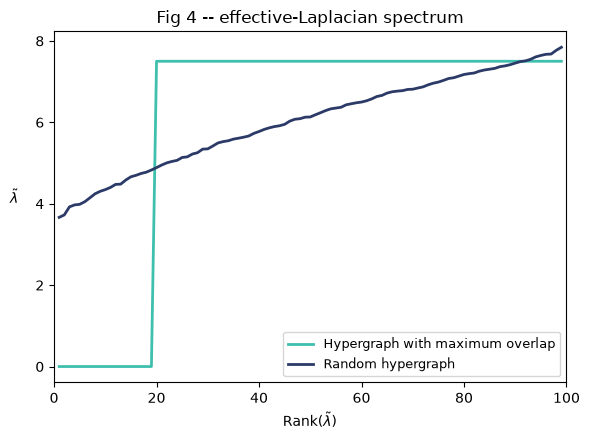

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(np.arange(1,N), eig_m[1:], color="#3fbfae", lw=2, label="Hypergraph with maximum overlap")
ax.plot(np.arange(1,N), eig_r[1:], color="#2b3a67", lw=2, label="Random hypergraph")
ax.set_xlabel(r"Rank($\tilde\lambda$)"); ax.set_ylabel(r"$\tilde\lambda$", rotation=0, labelpad=15)
ax.legend(fontsize=9); ax.set_title("Fig 4 -- effective-Laplacian spectrum")
ax.set_xlim([0, 100]);
ax.set_yticks(np.arange(0, 9, 2));
plt.tight_layout(); plt.show()